# Composite Market Risk Indicator

> **Live-data notebook.** Run all cells from top to bottom. One UTC timestamp is shared across the VIX, SKEW, CAPE, and composite calculations; saved outputs represent the latest committed execution.


Notebook run timestamp (UTC): 2026-07-27T03:05:15.100920+00:00
As of: 2026-07-27

VIX latest daily date used: 2026-07-24
VIX latest value used as current-month close: 18.58

SKEW latest daily date used: 2026-07-24
SKEW latest value used as current-month close: 147.28

----- VIX Bubble Risk -----
Model date: 2026-07-31
Latest value: 18.58
Risk: 45.57 %
Display sigma: -0.1112 SIG
Raw Z: 0.1112
Deviation: 0.018309
Deviation 10Y Avg: 0.004528
Deviation 10Y Std: 0.123915

----- SKEW Risk -----
Model date: 2026-07-31
Latest value: 147.28
Risk: 55.19 %
Display sigma: 0.1305 SIG
Raw Z: 0.1305
Deviation: 0.015471
Deviation 10Y Avg: 0.013206
Deviation 10Y Std: 0.017355

----- Valuation Risk -----
Model date: 2026-07-24
Latest value: 40.46
Risk: 66.09 %
Display sigma: 0.415 SIG
Raw Z: 0.415
Deviation: 0.244693
Deviation 10Y Avg: 0.195196
Deviation 10Y Std: 0.119281

----- Composite Risk -----
Model date: 2026-07-27
Risk: 55.62 %
Display sigma: 0.1413 SIG
Raw Z: 0.1413



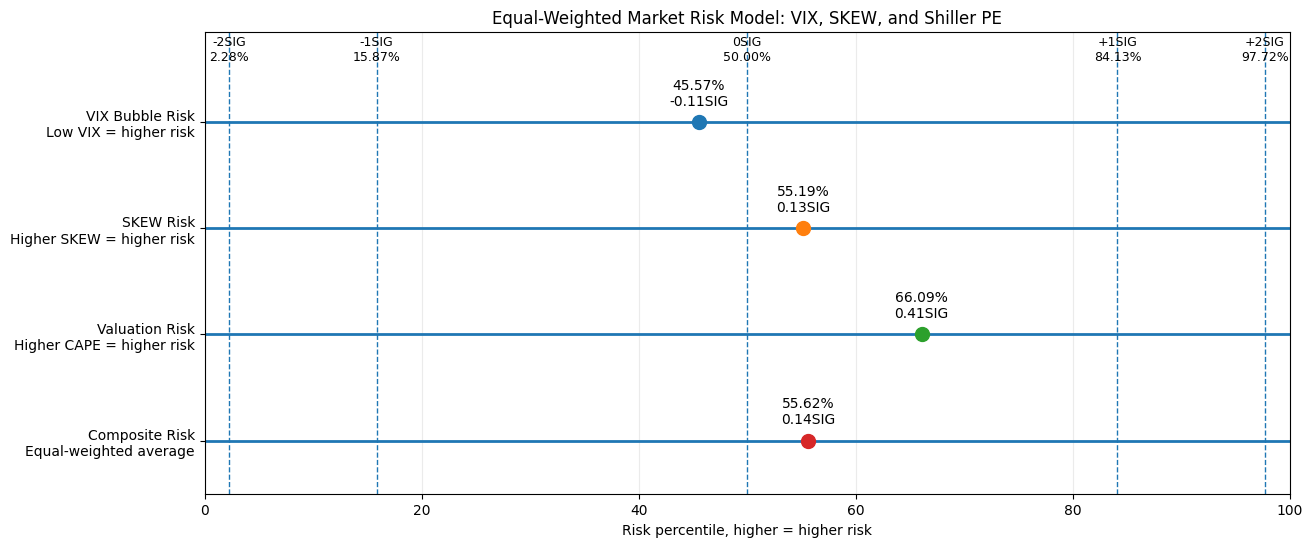

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

# ============================================================
# 3-Factor Market Risk Model
#
# 1. VIX Bubble Risk
#    - VIX and SKEW are treated as approximately log-normal.
#    - VIX: low VIX = complacency / bubble risk high.
#    - Risk = 1 - NORMDIST(...)
#
# 2. SKEW Risk
#    - Log SKEW is used.
#    - SKEW has structural post-GFC trend change, so Step 3 trend correction matters.
#    - Higher SKEW = higher tail-risk pricing.
#    - Risk = NORMDIST(...)
#
# 3. Shiller PE / CAPE Valuation Risk
#    - CAPE itself is used, not log CAPE.
#    - Higher CAPE = higher valuation risk.
#    - Risk = NORMDIST(...)
#
# 4. Composite Risk
#    - Equal-weighted average of the three risk percentiles.
# ============================================================

# -------------------------
# Settings
# -------------------------

RUN_TIMESTAMP_UTC = pd.Timestamp.now(tz="UTC")
today = RUN_TIMESTAMP_UTC.tz_localize(None).normalize()
print(f"Notebook run timestamp (UTC): {RUN_TIMESTAMP_UTC.isoformat()}")

# Step2 and Step3 each use 10-year rolling windows.
# To calculate the latest risk, around 20 years of data is needed.
# 21 years gives a small buffer.
start_date = today - relativedelta(years=21)

ROLLING_MONTHS = 120


# ============================================================
# Helper 1: Get monthly close from yfinance daily data
# Past months: monthly close
# Current month: latest daily close used as provisional monthly close
# ============================================================

def get_monthly_from_yfinance(ticker, close_name):
    daily = yf.download(
        ticker,
        start=start_date.strftime("%Y-%m-%d"),
        end=(today + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        interval="1d",
        auto_adjust=False,
        progress=False
    )

    if isinstance(daily.columns, pd.MultiIndex):
        daily.columns = daily.columns.get_level_values(0)

    daily = daily[["Close"]].dropna()
    daily = daily.rename(columns={"Close": close_name})

    latest_date = daily.index[-1]
    latest_value = daily[close_name].iloc[-1]

    monthly = daily.resample("ME").last()

    # Use latest daily close as provisional current-month close
    current_month_end = today + pd.offsets.MonthEnd(0)
    monthly.loc[current_month_end, close_name] = latest_value

    monthly = monthly.sort_index()

    return monthly, latest_date, latest_value


# ============================================================
# Helper 2: VIX Bubble Risk
#
# Step 1: Log VIX
# Step 2: Deviation = (Log VIX - 10Y Log Avg) / 10Y Log Avg
# Step 3: 10Y rolling average and stdev of deviation
# Step 4: VIX Bubble Risk = 1 - NORMDIST(...)
#
# Low VIX = higher complacency / bubble risk
# Display sigma is reversed so that higher sigma = higher bubble risk
# ============================================================

def calc_vix_bubble_risk(monthly, value_col):
    df = monthly.copy()

    df["Log_Value"] = np.log(df[value_col])

    df["Log_10Y_Avg"] = df["Log_Value"].rolling(ROLLING_MONTHS).mean()

    df["Deviation"] = (
        df["Log_Value"] - df["Log_10Y_Avg"]
    ) / df["Log_10Y_Avg"]

    df["Dev_10Y_Avg"] = df["Deviation"].rolling(ROLLING_MONTHS).mean()
    df["Dev_10Y_Std"] = df["Deviation"].rolling(ROLLING_MONTHS).std()

    df["Raw_Z"] = (
        df["Deviation"] - df["Dev_10Y_Avg"]
    ) / df["Dev_10Y_Std"]

    # VIX is inverted:
    # lower VIX = higher bubble/complacency risk
    df["Risk"] = 1 - norm.cdf(df["Raw_Z"])

    latest = df.dropna().iloc[-1]

    return {
        "name": "VIX Bubble Risk",
        "risk_pct": float(latest["Risk"] * 100),
        "display_sigma": float(-latest["Raw_Z"]),
        "raw_z": float(latest["Raw_Z"]),
        "latest_value": float(latest[value_col]),
        "model_date": latest.name.date(),
        "deviation": float(latest["Deviation"]),
        "dev_avg": float(latest["Dev_10Y_Avg"]),
        "dev_std": float(latest["Dev_10Y_Std"])
    }


# ============================================================
# Helper 3: Log-based high-risk index
#
# Used for SKEW.
# Higher value = higher risk.
#
# Step 1: Log value
# Step 2: Deviation = (Log value - 10Y Log Avg) / 10Y Log Avg
# Step 3: 10Y rolling average and stdev of deviation
# Step 4: Risk = NORMDIST(...)
# ============================================================

def calc_log_high_risk(monthly, value_col, name):
    df = monthly.copy()

    df["Log_Value"] = np.log(df[value_col])

    df["Log_10Y_Avg"] = df["Log_Value"].rolling(ROLLING_MONTHS).mean()

    df["Deviation"] = (
        df["Log_Value"] - df["Log_10Y_Avg"]
    ) / df["Log_10Y_Avg"]

    df["Dev_10Y_Avg"] = df["Deviation"].rolling(ROLLING_MONTHS).mean()
    df["Dev_10Y_Std"] = df["Deviation"].rolling(ROLLING_MONTHS).std()

    df["Z"] = (
        df["Deviation"] - df["Dev_10Y_Avg"]
    ) / df["Dev_10Y_Std"]

    df["Risk"] = norm.cdf(df["Z"])

    latest = df.dropna().iloc[-1]

    return {
        "name": name,
        "risk_pct": float(latest["Risk"] * 100),
        "display_sigma": float(latest["Z"]),
        "raw_z": float(latest["Z"]),
        "latest_value": float(latest[value_col]),
        "model_date": latest.name.date(),
        "deviation": float(latest["Deviation"]),
        "dev_avg": float(latest["Dev_10Y_Avg"]),
        "dev_std": float(latest["Dev_10Y_Std"])
    }


# ============================================================
# Helper 4: Get Shiller PE / CAPE from Multpl
# ============================================================

def get_cape_monthly_from_multpl():
    url = "https://www.multpl.com/shiller-pe/table/by-month"

    tables = pd.read_html(url)
    cape = tables[0].copy()
    cape.columns = ["Date", "CAPE"]

    cape["Date"] = pd.to_datetime(cape["Date"], errors="coerce")

    cape["CAPE"] = (
        cape["CAPE"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.extract(r"([0-9]+\.?[0-9]*)")[0]
        .astype(float)
    )

    cape = cape.dropna()
    cape = cape.sort_values("Date").set_index("Date")

    return cape


# ============================================================
# Helper 5: CAPE Valuation Risk
#
# Step 1: Deviation = (CAPE - 10Y Avg CAPE) / 10Y Avg CAPE
# Step 2: 10Y rolling average and stdev of deviation
# Step 3: Valuation Risk = NORMDIST(...)
#
# Higher CAPE = higher valuation risk
# ============================================================

def calc_cape_valuation_risk(monthly, value_col="CAPE"):
    df = monthly.copy()

    df["Value_10Y_Avg"] = df[value_col].rolling(ROLLING_MONTHS).mean()

    df["Deviation"] = (
        df[value_col] - df["Value_10Y_Avg"]
    ) / df["Value_10Y_Avg"]

    df["Dev_10Y_Avg"] = df["Deviation"].rolling(ROLLING_MONTHS).mean()
    df["Dev_10Y_Std"] = df["Deviation"].rolling(ROLLING_MONTHS).std()

    df["Z"] = (
        df["Deviation"] - df["Dev_10Y_Avg"]
    ) / df["Dev_10Y_Std"]

    df["Risk"] = norm.cdf(df["Z"])

    latest = df.dropna().iloc[-1]

    return {
        "name": "Valuation Risk",
        "risk_pct": float(latest["Risk"] * 100),
        "display_sigma": float(latest["Z"]),
        "raw_z": float(latest["Z"]),
        "latest_value": float(latest[value_col]),
        "model_date": latest.name.date(),
        "deviation": float(latest["Deviation"]),
        "dev_avg": float(latest["Dev_10Y_Avg"]),
        "dev_std": float(latest["Dev_10Y_Std"])
    }


# ============================================================
# Data fetch
# ============================================================

vix_monthly, vix_latest_date, vix_latest_value = get_monthly_from_yfinance(
    "^VIX",
    "VIX_Close"
)

skew_monthly, skew_latest_date, skew_latest_value = get_monthly_from_yfinance(
    "^SKEW",
    "SKEW_Close"
)

cape_monthly = get_cape_monthly_from_multpl()


# ============================================================
# Risk calculations
# ============================================================

vix_result = calc_vix_bubble_risk(vix_monthly, "VIX_Close")

skew_result = calc_log_high_risk(
    skew_monthly,
    "SKEW_Close",
    "SKEW Risk"
)

cape_result = calc_cape_valuation_risk(
    cape_monthly,
    "CAPE"
)

base_results = [vix_result, skew_result, cape_result]


# ============================================================
# Equal-weighted composite
# ============================================================

composite_risk = np.mean([r["risk_pct"] for r in base_results])

# Convert percentile back into sigma
composite_sigma = norm.ppf(composite_risk / 100)

composite_result = {
    "name": "Composite Risk",
    "risk_pct": float(composite_risk),
    "display_sigma": float(composite_sigma),
    "raw_z": float(composite_sigma),
    "latest_value": np.nan,
    "model_date": today.date(),
    "deviation": np.nan,
    "dev_avg": np.nan,
    "dev_std": np.nan
}

results = base_results + [composite_result]


# ============================================================
# Print summary
# ============================================================

print("As of:", today.date())
print()

print("VIX latest daily date used:", vix_latest_date.date())
print("VIX latest value used as current-month close:", round(float(vix_latest_value), 4))
print()

print("SKEW latest daily date used:", skew_latest_date.date())
print("SKEW latest value used as current-month close:", round(float(skew_latest_value), 4))
print()

for r in results:
    print("-----", r["name"], "-----")
    print("Model date:", r["model_date"])

    if not np.isnan(r["latest_value"]):
        print("Latest value:", round(r["latest_value"], 4))

    print("Risk:", round(r["risk_pct"], 2), "%")
    print("Display sigma:", round(r["display_sigma"], 4), "SIG")
    print("Raw Z:", round(r["raw_z"], 4))

    if not np.isnan(r["deviation"]):
        print("Deviation:", round(r["deviation"], 6))
        print("Deviation 10Y Avg:", round(r["dev_avg"], 6))
        print("Deviation 10Y Std:", round(r["dev_std"], 6))

    print()


# ============================================================
# Combined visualization
# ============================================================

sigma_levels = {
    "-2SIG": norm.cdf(-2) * 100,
    "-1SIG": norm.cdf(-1) * 100,
    "0SIG":  norm.cdf(0) * 100,
    "+1SIG": norm.cdf(1) * 100,
    "+2SIG": norm.cdf(2) * 100,
}

y_positions = {
    "VIX Bubble Risk": 4,
    "SKEW Risk": 3,
    "Valuation Risk": 2,
    "Composite Risk": 1,
}

y_labels = [
    "VIX Bubble Risk\nLow VIX = higher risk",
    "SKEW Risk\nHigher SKEW = higher risk",
    "Valuation Risk\nHigher CAPE = higher risk",
    "Composite Risk\nEqual-weighted average"
]

plt.figure(figsize=(14, 6))

# Horizontal risk lines and current points
for r in results:
    y = y_positions[r["name"]]

    plt.hlines(y, 0, 100, linewidth=2)
    plt.plot(r["risk_pct"], y, marker="o", markersize=10)

    plt.text(
        r["risk_pct"],
        y + 0.13,
        f"{r['risk_pct']:.2f}%\n{r['display_sigma']:.2f}SIG",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Sigma reference lines
for label, x in sigma_levels.items():
    plt.axvline(x, linestyle="--", linewidth=1)

    plt.text(
        x,
        4.55,
        f"{label}\n{x:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.yticks(
    [4, 3, 2, 1],
    y_labels
)

plt.xlim(0, 100)
plt.ylim(0.5, 4.85)
plt.xlabel("Risk percentile, higher = higher risk")
plt.title("Equal-Weighted Market Risk Model: VIX, SKEW, and Shiller PE")
plt.grid(axis="x", alpha=0.25)

plt.show()

=== VIX Bubble Risk Latest Value ===
As of: 2026-07-27
Latest VIX date used: 2026-07-24
Latest VIX used as current-month close: 18.5800
Model month: 2026-07-31

Log Deviation: 0.018309
Deviation 10Y Avg: 0.004528
Deviation 10Y Std: 0.123915

Raw Z-score: 0.1112
Display Sigma: -0.1112
VIX Bubble Risk: 45.57%

=== Sigma Reference ===
-2SIG: 2.28%
-1SIG: 15.87%
0SIG: 50.00%
+1SIG: 84.13%
+2SIG: 97.72%


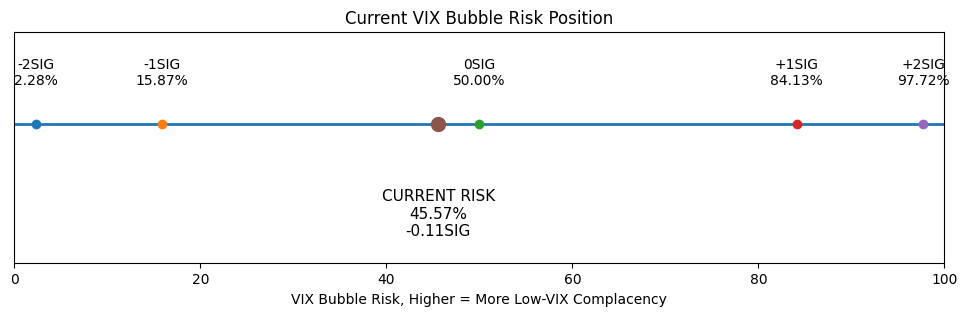

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

# =========================
# VIX Bubble Risk Model
# Completed months use month-end closes.
# The current month uses the latest available VIX close as a provisional month-end close.
# Risk increases as VIX falls.
# Positive display sigma indicates higher bubble risk.
# =========================

# Current date
today = RUN_TIMESTAMP_UTC.tz_localize(None).normalize()

# Download 21 years because Steps 2 and 3 each require a 10-year rolling window.
start_date = today - relativedelta(years=21)

# Download daily VIX data
daily = yf.download(
    "^VIX",
    start=start_date.strftime("%Y-%m-%d"),
    end=(today + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Flatten yfinance MultiIndex columns when present
if isinstance(daily.columns, pd.MultiIndex):
    daily.columns = daily.columns.get_level_values(0)

# Use only the Close column
daily = daily[["Close"]].dropna()
daily = daily.rename(columns={"Close": "VIX_Close"})

# Latest available VIX close
latest_date = daily.index[-1]
latest_vix = daily["VIX_Close"].iloc[-1]

# Build the monthly close series
monthly = daily.resample("ME").last()

# Use the latest available VIX close as the provisional close for the current month.
current_month_end = today + pd.offsets.MonthEnd(0)
monthly.loc[current_month_end, "VIX_Close"] = latest_vix
monthly = monthly.sort_index()

# Step 1: Log VIX
monthly["Log_VIX"] = np.log(monthly["VIX_Close"])

# Step 2: 10-year rolling mean of log values
monthly["Log_10Y_Avg"] = monthly["Log_VIX"].rolling(120).mean()

# Step 2: Relative deviation from the rolling log mean
monthly["Log_Deviation"] = (
    monthly["Log_VIX"] - monthly["Log_10Y_Avg"]
) / monthly["Log_10Y_Avg"]

# Step 3: 10-year rolling mean and standard deviation of the deviation
monthly["Dev_10Y_Avg"] = monthly["Log_Deviation"].rolling(120).mean()
monthly["Dev_10Y_Std"] = monthly["Log_Deviation"].rolling(120).std()

# Raw z-score
monthly["Raw_Z"] = (
    monthly["Log_Deviation"] - monthly["Dev_10Y_Avg"]
) / monthly["Dev_10Y_Std"]

# Step 4: VIX Risk = 1 - NORMDIST
# Lower VIX implies greater complacency and bubble risk.
monthly["VIX_Bubble_Risk"] = 1 - norm.cdf(monthly["Raw_Z"])

# Display sigma
# Reverse the Raw_Z sign so higher display values indicate higher risk.
monthly["Display_Sigma"] = -monthly["Raw_Z"]

# Latest complete model row
latest_row = monthly.dropna().iloc[-1]

current_risk = float(latest_row["VIX_Bubble_Risk"]) * 100
display_sigma_current = float(latest_row["Display_Sigma"])
raw_z_current = float(latest_row["Raw_Z"])

# Display-sigma reference levels
# +2 SIG corresponds to the 97.72% high-risk percentile.
display_sigma_levels = {
    "-2SIG": (1 - norm.cdf(2)) * 100,
    "-1SIG": (1 - norm.cdf(1)) * 100,
    "0SIG":  (1 - norm.cdf(0)) * 100,
    "+1SIG": (1 - norm.cdf(-1)) * 100,
    "+2SIG": (1 - norm.cdf(-2)) * 100,
}

# =========================
# Display numeric results
# =========================

print("=== VIX Bubble Risk Latest Value ===")
print(f"As of: {today.date()}")
print(f"Latest VIX date used: {latest_date.date()}")
print(f"Latest VIX used as current-month close: {float(latest_vix):.4f}")
print(f"Model month: {latest_row.name.date()}")
print("")
print(f"Log Deviation: {float(latest_row['Log_Deviation']):.6f}")
print(f"Deviation 10Y Avg: {float(latest_row['Dev_10Y_Avg']):.6f}")
print(f"Deviation 10Y Std: {float(latest_row['Dev_10Y_Std']):.6f}")
print("")
print(f"Raw Z-score: {raw_z_current:.4f}")
print(f"Display Sigma: {display_sigma_current:.4f}")
print(f"VIX Bubble Risk: {current_risk:.2f}%")

print("")
print("=== Sigma Reference ===")
for label, value in display_sigma_levels.items():
    print(f"{label}: {value:.2f}%")

# =========================
# Visualization
# =========================

plt.figure(figsize=(12, 3))
plt.hlines(1, 0, 100, linewidth=2)

# Sigma reference points
for label, x in display_sigma_levels.items():
    plt.plot(x, 1, marker="o")
    plt.text(
        x, 1.08,
        f"{label}\n{x:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Current value
plt.plot(current_risk, 1, marker="o", markersize=10)
plt.text(
    current_risk, 0.86,
    f"CURRENT RISK\n{current_risk:.2f}%\n{display_sigma_current:+.2f}SIG",
    ha="center",
    va="top",
    fontsize=11
)

plt.xlim(0, 100)
plt.ylim(0.7, 1.2)
plt.yticks([])
plt.xlabel("VIX Bubble Risk, Higher = More Low-VIX Complacency")
plt.title("Current VIX Bubble Risk Position")
plt.show()

As of: 2026-07-27
Latest SKEW date used: 2026-07-24
Latest SKEW used as current-month close: 147.28
Model month: 2026-07-31
Log Deviation: 0.015471
Deviation 10Y Avg: 0.013206
Deviation 10Y Std: 0.017355
Current Z-score: 0.1305
Current SKEW Risk: 55.19 %


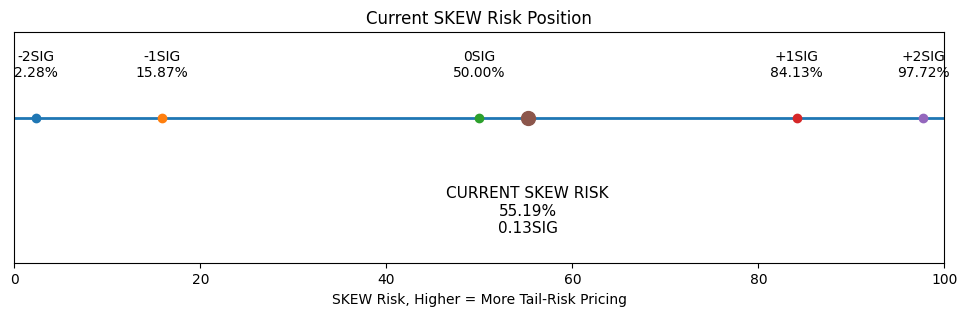

In [4]:

import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

# =========================
# SKEW Risk Model
# Completed months use month-end closes.
# The current month uses the latest available SKEW close as a provisional month-end close.
# Risk increases as SKEW rises.
# Step 4: SKEW Risk = NORMDIST(...)
# =========================

today = RUN_TIMESTAMP_UTC.tz_localize(None).normalize()

# Download 21 years because Steps 2 and 3 each require a 10-year rolling window.
start_date = today - relativedelta(years=21)

# Download daily SKEW data
daily = yf.download(
    "^SKEW",
    start=start_date.strftime("%Y-%m-%d"),
    end=(today + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Flatten yfinance MultiIndex columns when present
if isinstance(daily.columns, pd.MultiIndex):
    daily.columns = daily.columns.get_level_values(0)

# Use only the Close column
daily = daily[["Close"]].dropna()
daily = daily.rename(columns={"Close": "SKEW_Close"})

# Latest available SKEW close
latest_date = daily.index[-1]
latest_skew = daily["SKEW_Close"].iloc[-1]

# Build the monthly close series
monthly = daily.resample("ME").last()

# Use the latest available SKEW close as the provisional close for the current month.
current_month_end = today + pd.offsets.MonthEnd(0)
monthly.loc[current_month_end, "SKEW_Close"] = latest_skew

# Step 1: Log SKEW
monthly["Log_SKEW"] = np.log(monthly["SKEW_Close"])

# Step 2: 10-year rolling mean of log values
monthly["Log_10Y_Avg"] = monthly["Log_SKEW"].rolling(120).mean()

# Step 2: Relative deviation from the rolling log mean
monthly["Log_Deviation"] = (
    monthly["Log_SKEW"] - monthly["Log_10Y_Avg"]
) / monthly["Log_10Y_Avg"]

# Step 3: 10-year rolling mean and standard deviation of the deviation
# Adjust for SKEW's structural upward trend at this stage.
monthly["Dev_10Y_Avg"] = monthly["Log_Deviation"].rolling(120).mean()
monthly["Dev_10Y_Std"] = monthly["Log_Deviation"].rolling(120).std()

# Z-score
monthly["Z_Score"] = (
    monthly["Log_Deviation"] - monthly["Dev_10Y_Avg"]
) / monthly["Dev_10Y_Std"]

# Step 4: SKEW Risk = NORMDIST
# Higher SKEW implies higher risk, so no complement (1 -) is applied.
monthly["SKEW_Risk"] = norm.cdf(monthly["Z_Score"])

# Latest complete model row
latest_row = monthly.dropna().iloc[-1]

z_current = latest_row["Z_Score"]
current_risk = latest_row["SKEW_Risk"] * 100

# Sigma reference levels
sigma_levels = {
    "-2SIG": norm.cdf(-2) * 100,
    "-1SIG": norm.cdf(-1) * 100,
    "0SIG":  norm.cdf(0) * 100,
    "+1SIG": norm.cdf(1) * 100,
    "+2SIG": norm.cdf(2) * 100,
}

# =========================
# Display results
# =========================

print("As of:", today.date())
print("Latest SKEW date used:", latest_date.date())
print("Latest SKEW used as current-month close:", round(float(latest_skew), 4))
print("Model month:", latest_row.name.date())
print("Log Deviation:", round(float(latest_row["Log_Deviation"]), 6))
print("Deviation 10Y Avg:", round(float(latest_row["Dev_10Y_Avg"]), 6))
print("Deviation 10Y Std:", round(float(latest_row["Dev_10Y_Std"]), 6))
print("Current Z-score:", round(float(z_current), 4))
print("Current SKEW Risk:", round(float(current_risk), 2), "%")

# =========================
# Visualization
# =========================

plt.figure(figsize=(12, 3))
plt.hlines(1, 0, 100, linewidth=2)

for label, x in sigma_levels.items():
    plt.plot(x, 1, marker="o")
    plt.text(
        x, 1.08,
        f"{label}\n{x:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.plot(current_risk, 1, marker="o", markersize=10)
plt.text(
    current_risk,
    0.86,
    f"CURRENT SKEW RISK\n{current_risk:.2f}%\n{z_current:.2f}SIG",
    ha="center",
    va="top",
    fontsize=11
)

plt.xlim(0, 100)
plt.ylim(0.7, 1.18)
plt.yticks([])
plt.xlabel("SKEW Risk, Higher = More Tail-Risk Pricing")
plt.title("Current SKEW Risk Position")
plt.show()

Latest CAPE date: 2026-07-24
Latest Shiller PE / CAPE: 40.46
10Y CAPE Avg: 32.506
Deviation: 0.244693
Deviation 10Y Avg: 0.195196
Deviation 10Y Std: 0.119281
Current Z-score: 0.415
Current Valuation Risk: 66.09 %


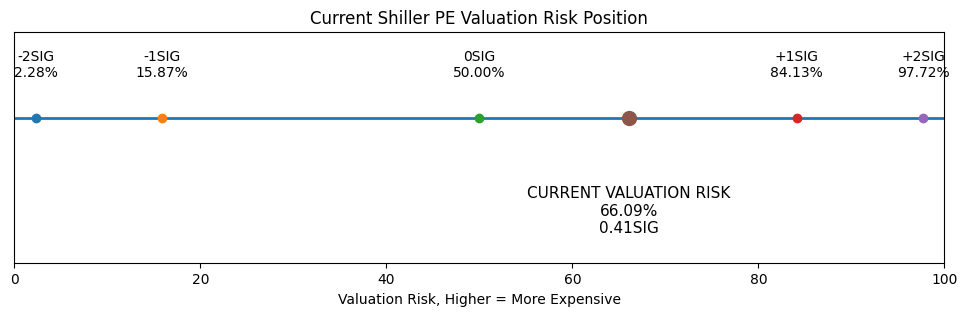

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# =========================
# Shiller PE / CAPE Valuation Risk Model
# Step 1: Calculate deviation from the 10-year rolling mean
# Step 2: Adjust the trend using the deviation's 10-year rolling mean and standard deviation
# Step 3: Valuation Risk = NORMDIST(...)
# Higher values indicate a more expensive equity market.
# =========================

url = "https://www.multpl.com/shiller-pe/table/by-month"

# Download the HTML table from Multpl
tables = pd.read_html(url)
cape = tables[0].copy()

# Standardize column names
cape.columns = ["Date", "Shiller_PE"]

# Convert numeric and date fields
cape["Date"] = pd.to_datetime(cape["Date"], errors="coerce")
cape["Shiller_PE"] = (
    cape["Shiller_PE"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"([0-9]+\.?[0-9]*)")[0]
    .astype(float)
)

cape = cape.dropna()

# Sort chronologically
cape = cape.sort_values("Date").set_index("Date")

# Treat the data as a monthly series
monthly = cape.copy()
monthly = monthly.rename(columns={"Shiller_PE": "CAPE"})

# Step 1: 10-year rolling mean
monthly["CAPE_10Y_Avg"] = monthly["CAPE"].rolling(120).mean()

# Step 1: Relative deviation
monthly["Deviation"] = (
    monthly["CAPE"] - monthly["CAPE_10Y_Avg"]
) / monthly["CAPE_10Y_Avg"]

# Step 2: 10-year rolling mean and standard deviation of the deviation
# Adjust for long-run shifts in valuation levels at this stage.
monthly["Dev_10Y_Avg"] = monthly["Deviation"].rolling(120).mean()
monthly["Dev_10Y_Std"] = monthly["Deviation"].rolling(120).std()

# Z-score
monthly["Z_Score"] = (
    monthly["Deviation"] - monthly["Dev_10Y_Avg"]
) / monthly["Dev_10Y_Std"]

# Step 3: Valuation Risk = NORMDIST
# Higher values imply richer valuation, so no complement (1 -) is applied.
monthly["Valuation_Risk"] = norm.cdf(monthly["Z_Score"])

# Latest complete model row
latest_row = monthly.dropna().iloc[-1]

z_current = latest_row["Z_Score"]
current_risk = latest_row["Valuation_Risk"] * 100

# Sigma reference levels
sigma_levels = {
    "-2SIG": norm.cdf(-2) * 100,
    "-1SIG": norm.cdf(-1) * 100,
    "0SIG":  norm.cdf(0) * 100,
    "+1SIG": norm.cdf(1) * 100,
    "+2SIG": norm.cdf(2) * 100,
}

# =========================
# Display results
# =========================

print("Latest CAPE date:", latest_row.name.date())
print("Latest Shiller PE / CAPE:", round(float(latest_row["CAPE"]), 4))
print("10Y CAPE Avg:", round(float(latest_row["CAPE_10Y_Avg"]), 4))
print("Deviation:", round(float(latest_row["Deviation"]), 6))
print("Deviation 10Y Avg:", round(float(latest_row["Dev_10Y_Avg"]), 6))
print("Deviation 10Y Std:", round(float(latest_row["Dev_10Y_Std"]), 6))
print("Current Z-score:", round(float(z_current), 4))
print("Current Valuation Risk:", round(float(current_risk), 2), "%")

# =========================
# Visualization
# =========================

plt.figure(figsize=(12, 3))
plt.hlines(1, 0, 100, linewidth=2)

for label, x in sigma_levels.items():
    plt.plot(x, 1, marker="o")
    plt.text(
        x,
        1.08,
        f"{label}\n{x:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.plot(current_risk, 1, marker="o", markersize=10)
plt.text(
    current_risk,
    0.86,
    f"CURRENT VALUATION RISK\n{current_risk:.2f}%\n{z_current:.2f}SIG",
    ha="center",
    va="top",
    fontsize=11
)

plt.xlim(0, 100)
plt.ylim(0.7, 1.18)
plt.yticks([])
plt.xlabel("Valuation Risk, Higher = More Expensive")
plt.title("Current Shiller PE Valuation Risk Position")
plt.show()